# Lag this shit

In [49]:
# LightGBM imports
import lightgbm as lgb

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

# Label encoding
from sklearn.preprocessing import LabelEncoder

In [50]:
filepath_train = 'data/ais_train.csv'
filepath_test = 'data/ais_test.csv'

# Load AIS historical data
train = pd.read_csv(filepath_train, sep ='|')


In [51]:
# Replace special values with NaN
train.replace({'rot': {127: np.nan, -127: np.nan, -128: np.nan},
               'sog': {102.3: np.nan},
               'cog': {360: np.nan},
               'heading': {511: np.nan}}, inplace=True)

# drop columns except vesselId, sog, cog, heading, rot, time, latitude, longitude
train = train[['time','vesselId', 'sog', 'cog', 'heading', 'rot', 'latitude', 'longitude']]

# Convert time to datetime
train['time'] = pd.to_datetime(train['time'])

# Time difference between two consecutive rows in seconds for each vessel
train['time_diff'] = train.groupby('vesselId')['time'].diff().dt.total_seconds()

# Label encoding for vesselId
LabelEncoder_vesselId = LabelEncoder()
train['vesselId'] = LabelEncoder_vesselId.fit_transform(train['vesselId'])

# drop rows with NaN values
train = train.dropna()

display(train)

,time,vesselId,sog,cog,heading,rot,latitude,longitude,time_diff
143,2024-01-01 00:17:17,71,0.1,73.9,120.0,12.0,-26.77586,153.23453,361.0
145,2024-01-01 00:18:57,175,0.1,150.7,251.0,0.0,38.47387,15.91592,159.0
146,2024-01-01 00:19:39,211,12.9,56.4,56.0,-16.0,33.90815,130.92404,334.0
148,2024-01-01 00:20:35,682,0.0,114.5,275.0,0.0,43.44237,-3.82309,720.0
149,2024-01-01 00:21:37,161,0.0,210.4,122.0,-5.0,40.68658,29.31613,360.0
...,...,...,...,...,...,...,...,...,...
1522060,2024-05-07 23:59:07,682,13.4,359.1,1.0,0.0,52.19131,-5.82223,1270.0
1522061,2024-05-07 23:59:08,85,17.1,12.3,13.0,0.0,38.96142,-12.00502,1248.0
1522062,2024-05-07 23:59:08,459,14.9,269.8,270.0,-1.0,49.71372,-5.22042,1248.0
1522063,2024-05-07 23:59:08,596,18.7,8.0,6.0,0.0,38.27895,10.78280,1506.0


In [52]:
def lag_features(data, lags):
    data = data.copy()
    for lag in lags:
        data['sog_lag_' + str(lag)] = data.groupby('vesselId')['sog'].shift(lag)
        data['cog_lag_' + str(lag)] = data.groupby('vesselId')['cog'].shift(lag)
        data['heading_lag_' + str(lag)] = data.groupby('vesselId')['heading'].shift(lag)
        data['rot_lag_' + str(lag)] = data.groupby('vesselId')['rot'].shift(lag)
        data['latitude_lag_' + str(lag)] = data.groupby('vesselId')['latitude'].shift(lag)
        data['longitude_lag_' + str(lag)] = data.groupby('vesselId')['longitude'].shift(lag)
        data['time_diff_lag_' + str(lag)] = data.groupby('vesselId')['time_diff'].shift(lag)
    return data

train = lag_features(train, [1])

# Drop rows with NaN values
train = train.dropna()




display(train)

,time,vesselId,sog,cog,heading,rot,latitude,longitude,time_diff,sog_lag_1,cog_lag_1,heading_lag_1,rot_lag_1,latitude_lag_1,longitude_lag_1,time_diff_lag_1
291,2024-01-01 00:37:39,587,0.0,44.6,148.0,0.0,39.21009,9.10328,175.0,0.0,44.6,148.0,0.0,39.21007,9.10330,1263.0
293,2024-01-01 00:38:37,140,10.1,205.8,205.0,0.0,41.44703,-71.38101,531.0,11.1,228.0,227.0,0.0,41.46811,-71.36371,866.0
296,2024-01-01 00:44:36,682,0.0,114.5,275.0,0.0,43.44240,-3.82321,1441.0,0.0,114.5,275.0,0.0,43.44237,-3.82309,720.0
297,2024-01-01 00:46:32,156,0.0,259.7,323.0,-1.0,40.72221,29.48062,1080.0,0.0,23.8,323.0,0.0,40.72222,29.48063,1081.0
299,2024-01-01 00:48:15,464,10.9,334.7,334.0,0.0,40.59254,18.32469,700.0,10.6,334.9,335.0,0.0,40.56030,18.34426,1261.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1522060,2024-05-07 23:59:07,682,13.4,359.1,1.0,0.0,52.19131,-5.82223,1270.0,13.7,357.4,357.0,0.0,52.11105,-5.81341,7268.0
1522061,2024-05-07 23:59:08,85,17.1,12.3,13.0,0.0,38.96142,-12.00502,1248.0,17.2,11.2,13.0,0.0,38.86410,-12.03073,1224.0
1522062,2024-05-07 23:59:08,459,14.9,269.8,270.0,-1.0,49.71372,-5.22042,1248.0,15.1,268.8,270.0,-3.0,49.71447,-5.08697,1224.0
1522063,2024-05-07 23:59:08,596,18.7,8.0,6.0,0.0,38.27895,10.78280,1506.0,19.1,9.0,6.0,0.0,38.14875,10.75635,29783.0


In [53]:
# Split data into train and validation sort by time for each vessel

train = train.sort_values(by=['vesselId', 'time']).reset_index(drop=True)

# Drop time column
train_copy = train.drop(['time', 'sog', 'cog', 'heading', 'rot'], axis=1)

# print features in a list
display(train_copy.columns)

train_size = int(0.8 * train['vesselId'].nunique())

train_vesselIds = train_copy['vesselId'].unique()[:train_size]
val_vesselIds = train_copy['vesselId'].unique()[train_size:]

train_data = train_copy[train_copy['vesselId'].isin(train_vesselIds)]
val_data = train_copy[train_copy['vesselId'].isin(val_vesselIds)]

X_train = train_data.drop(['latitude', 'longitude'], axis=1)
y_train = train_data[['latitude', 'longitude']]
X_val = val_data.drop(['latitude', 'longitude'], axis=1)
y_val = val_data[['latitude', 'longitude']]

display(X_train.shape, y_train.shape, X_val.shape, y_val.shape)


Index(['vesselId', 'latitude', 'longitude', 'time_diff', 'sog_lag_1',
       'cog_lag_1', 'heading_lag_1', 'rot_lag_1', 'latitude_lag_1',
       'longitude_lag_1', 'time_diff_lag_1'],
      dtype='object')

(1041024, 9)

(1041024, 2)

(447623, 9)

(447623, 2)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.036386 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2065
[LightGBM] [Info] Number of data points in the train set: 1041024, number of used features: 9
[LightGBM] [Info] Start training from score 33.483827
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[158]	valid_0's rmse: 1.08184
Latitude RMSE: 1.0818400264194121
Latitude MAE: 0.28183591025529914
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.037081 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2065
[LightGBM] [Info] Number of data points in the train set: 1041024, number of used features: 9
[LightGBM] [Info] Start training from score 9.301292
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[270]	valid_0's rmse: 2

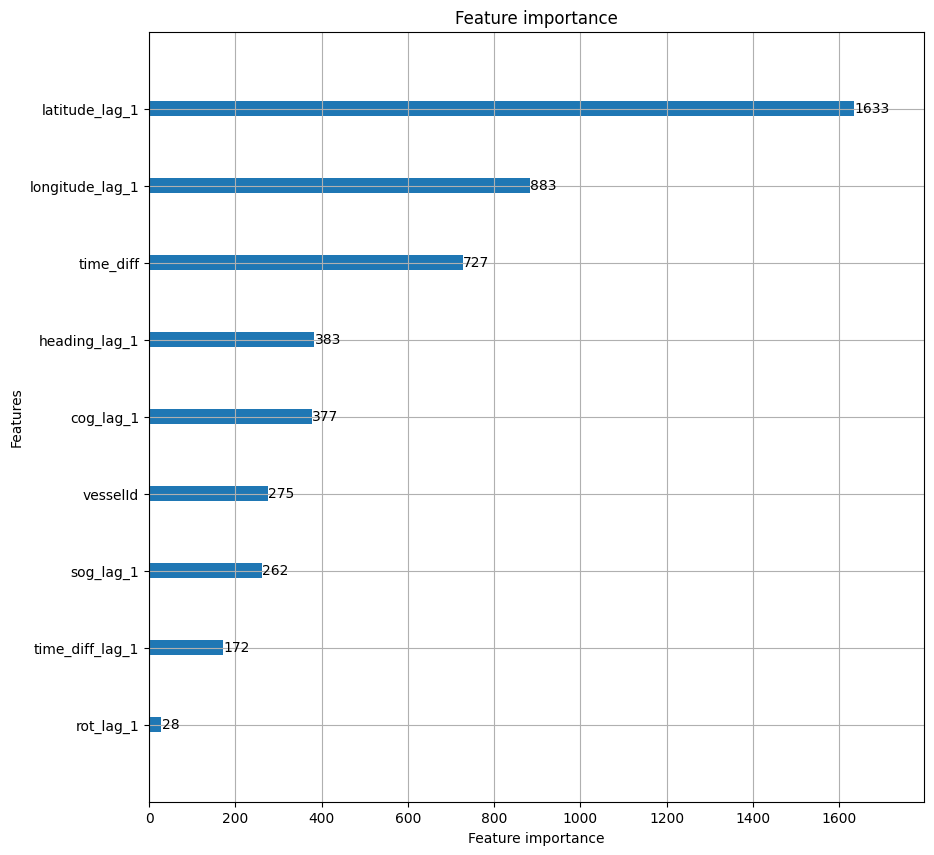

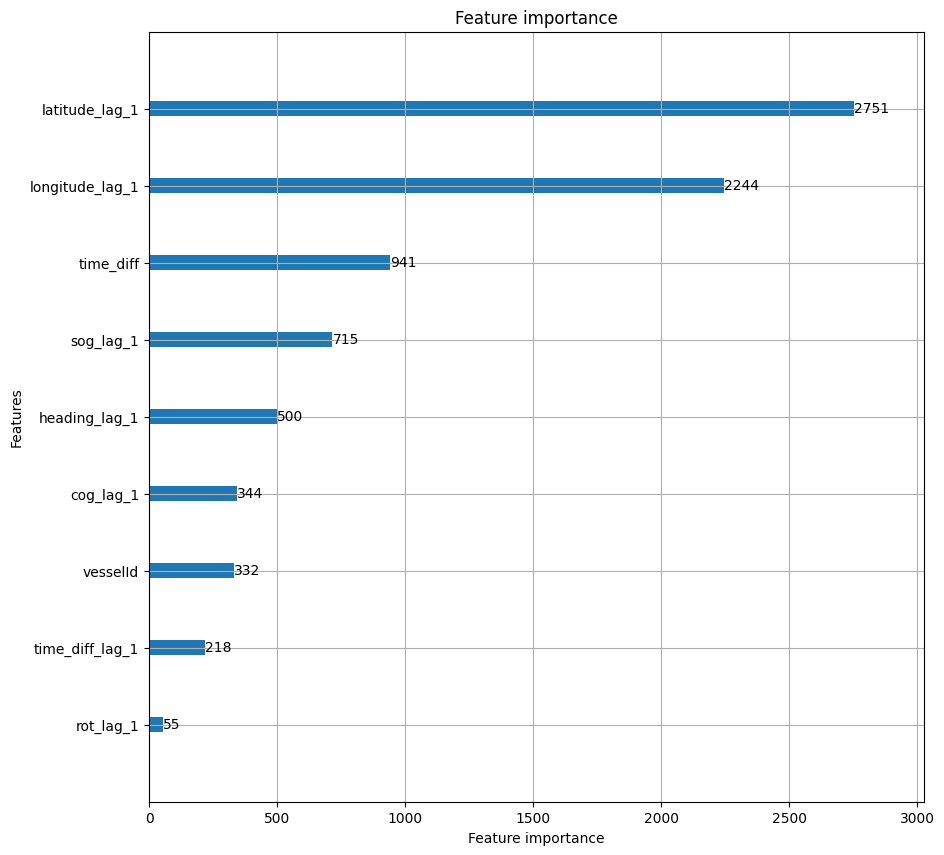

In [54]:
# LightGBM parameters
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting': 'gbdt',
    'num_leaves': 31,
    'feature_fraction': 0.9,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'learning_rate': 0.05,
    'verbose': 1,
    'early_stopping_rounds': 10
}

# Train LightGBM model for latitude
train_data_lat = lgb.Dataset(X_train, label=y_train['latitude'])
val_data_lat = lgb.Dataset(X_val, label=y_val['latitude'])
model_lat = lgb.train(params, train_data_lat, valid_sets=[val_data_lat], num_boost_round=1000)

# Predict on validation set for latitude
y_pred_lat = model_lat.predict(X_val)

# Evaluate model for latitude
rmse_lat = np.sqrt(mean_squared_error(y_val['latitude'], y_pred_lat))
print('Latitude RMSE:', rmse_lat)
mae_lat = np.mean(np.abs(y_val['latitude'] - y_pred_lat))
print('Latitude MAE:', mae_lat)

# Train LightGBM model for longitude
train_data_lon = lgb.Dataset(X_train, label=y_train['longitude'])
val_data_lon = lgb.Dataset(X_val, label=y_val['longitude'])
model_lon = lgb.train(params, train_data_lon, valid_sets=[val_data_lon], num_boost_round=1000)

# Predict on validation set for longitude
y_pred_lon = model_lon.predict(X_val)

# Evaluate model for longitude
rmse_lon = np.sqrt(mean_squared_error(y_val['longitude'], y_pred_lon))
print('Longitude RMSE:', rmse_lon)
mae_lon = np.mean(np.abs(y_val['longitude'] - y_pred_lon))
print('Longitude MAE:', mae_lon)

# Plot feature importance for latitude model
lgb.plot_importance(model_lat, figsize=(10, 10))
plt.show()

# Plot feature importance for longitude model
lgb.plot_importance(model_lon, figsize=(10, 10))
plt.show()


In [55]:
test = pd.read_csv(filepath_test, sep = ',')

# label encoding for vesselId
test['vesselId'] = LabelEncoder_vesselId.transform(test['vesselId'])

def time_diff(data):
    data = data.copy()
    data['time'] = pd.to_datetime(data['time'])
    data['time_diff'] = data.groupby('vesselId')['time'].diff().dt.total_seconds()
    data['time_diff'] = data['time_diff'].fillna(0)  # Replace NaNs with 0
    return data

test = time_diff(test)

# Drop scaling_factor and time columns
test = test.drop(['scaling_factor'], axis=1)

evaluation_set = test.copy()

display(test)

,ID,vesselId,time,time_diff
0,0,84,2024-05-08 00:03:16,0.0
1,1,623,2024-05-08 00:06:17,0.0
2,2,596,2024-05-08 00:10:02,0.0
3,3,542,2024-05-08 00:10:34,0.0
4,4,1,2024-05-08 00:12:27,0.0
...,...,...,...,...
51734,51734,48,2024-05-12 23:59:58,1355.0
51735,51735,110,2024-05-12 23:59:58,1243.0
51736,51736,610,2024-05-12 23:59:58,1240.0
51737,51737,574,2024-05-12 23:59:58,1248.0


In [56]:
from tqdm import tqdm

# Dictionary to store predictions for each vessel in the evaluation set
predictions = []

vessel_data = {
    vessel_id: data
    for vessel_id, data in train.groupby('vesselId')
}

features = ['vesselId', 'sog_lag_1', 'time_diff',
       'cog_lag_1', 'heading_lag_1', 'rot_lag_1', 'latitude_lag_1',
       'longitude_lag_1', 'time_diff_lag_1']


# Iterate over each vessel in the evaluation set with a progress bar
for vessel_id in tqdm(evaluation_set['vesselId'].unique(), desc="Predicting for vessels"):
    if vessel_id in vessel_data:
        # Get the historical data for the vessel
        df_vessel = vessel_data[vessel_id]
        # Create a dataframe from the last row
        last_row_df = pd.DataFrame([df_vessel.iloc[-1]])

        # Get the last row of the historical data ['sog', 'cog', 'heading', 'rot']
        last_row_df = last_row_df[['time', 'vesselId', 'sog', 'cog', 'heading', 'rot', 'latitude', 'longitude', 'time_diff']]
        last_row_df = last_row_df.rename(columns={'latitude': 'latitude_lag_1', 'longitude': 'longitude_lag_1', 'sog': 'sog_lag_1', 'cog': 'cog_lag_1', 'heading': 'heading_lag_1', 'rot': 'rot_lag_1', 'time_diff': 'time_diff_lag_1'})

         # Get all future timestamps for the vessel in the evaluation set
        vessel_timestamps = evaluation_set[evaluation_set['vesselId'] == vessel_id]['time']

        # Predict sequentially for each future timestamp
        for timestamp in vessel_timestamps:

            # Add timestamp to the last row dataframe and calculate time difference
            last_row_df['time'] = timestamp
            last_row_df['time_diff'] = (timestamp - last_row_df['time']).dt.total_seconds()
            # Drop time
            last_row_df = last_row_df.drop(['time'], axis=1)

            # Predict the next longitude and latitude
            y_pred_lat = model_lat.predict(last_row_df[features])
            y_pred_lon = model_lon.predict(last_row_df[features])

            predictions.append({
                'vessel_id': vessel_id,
                'timestamp': timestamp,
                'longitude': y_pred_lon.values[0],
                'latitude': y_pred_lat.values[0]
            })


            # Update the "last row" for the next prediction
            # Last_row = y_pred_lat, y_pred_lon, vesselId, time_diff, sog, cog, heading, rot
            last_row = pd.Series({
                'vesselId': vessel_id,
                'latitude_lag_1': y_pred_lat,
                'longitude_lag_1': y_pred_lon,
                'time_diff_lag_1': last_row_df['time_diff'],
                'sog_lag_1': last_row_df['sog_lag_1'],
                'cog_lag_1': last_row_df['cog_lag_1'],
                'heading_lag_1': last_row_df['heading_lag_1'],
                'rot_lag_1': last_row_df['rot_lag_1']
            })



display(predictions)







Predicting for vessels:   0%|          | 0/215 [00:00<?, ?it/s]


AttributeError: 'numpy.ndarray' object has no attribute 'values'

In [ ]:
# Get it back on the format of the test set
predictions_df = pd.DataFrame(predictions)
predictions_df['time'] = predictions_df['timestamp']
predictions_df = predictions_df.drop(['timestamp'], axis=1)
predictions_df = predictions_df.rename(columns={'vessel_id': 'vesselId'})

display(evaluation_set)
display(predictions_df)

# Back in original order and format by merging with the evaluation set
predictions_df = evaluation_set.merge(predictions_df, on=['vesselId', 'time'], how='left')

display(predictions_df)

,ID,vesselId,time,time_diff
0,0,84,2024-05-08 00:03:16,0.0
1,1,623,2024-05-08 00:06:17,0.0
2,2,596,2024-05-08 00:10:02,0.0
3,3,542,2024-05-08 00:10:34,0.0
4,4,1,2024-05-08 00:12:27,0.0
...,...,...,...,...
51734,51734,48,2024-05-12 23:59:58,1355.0
51735,51735,110,2024-05-12 23:59:58,1243.0
51736,51736,610,2024-05-12 23:59:58,1240.0
51737,51737,574,2024-05-12 23:59:58,1248.0


,vesselId,longitude,latitude,time
0,84,[-81.22791907471985],[31.4760498038215],2024-05-08 00:03:16
1,84,[-81.22791907471985],[31.4760498038215],2024-05-08 00:36:14
2,84,[-81.22791907471985],[31.4760498038215],2024-05-08 00:51:12
3,84,[-81.22791907471985],[31.4760498038215],2024-05-08 01:12:14
4,84,[-81.22791907471985],[31.4760498038215],2024-05-08 01:30:14
...,...,...,...,...
51734,539,[104.76234381621795],[1.7303043336783297],2024-05-12 22:25:40
51735,539,[104.76234381621795],[1.7303043336783297],2024-05-12 22:55:40
51736,539,[104.76234381621795],[1.7303043336783297],2024-05-12 23:13:40
51737,539,[104.76234381621795],[1.7303043336783297],2024-05-12 23:34:40


,ID,vesselId,time,time_diff,longitude,latitude
0,0,84,2024-05-08 00:03:16,0.0,[-81.22791907471985],[31.4760498038215]
1,1,623,2024-05-08 00:06:17,0.0,[119.17046641136425],[14.888754207877128]
2,2,596,2024-05-08 00:10:02,0.0,[9.896716615035782],[38.62286314410776]
3,3,542,2024-05-08 00:10:34,0.0,[174.1258061978555],[-42.01333115981803]
4,4,1,2024-05-08 00:12:27,0.0,[-7.024440056185544],[48.58504151946762]
...,...,...,...,...,...,...
51734,51734,48,2024-05-12 23:59:58,1355.0,[-77.56183760466011],[26.330322148306173]
51735,51735,110,2024-05-12 23:59:58,1243.0,[138.9554174653922],[41.30242589727792]
51736,51736,610,2024-05-12 23:59:58,1240.0,[140.63171335291628],[34.830775668600246]
51737,51737,574,2024-05-12 23:59:58,1248.0,[23.66449381263279],[58.817721646177716]
